# Achter de Schermen van het Aanbevelingssysteem

Welkom! Leuk dat je een kijkje neemt in de "keuken" van ons aanbevelingssysteem.
Je vraagt je misschien af: *Hoe weet dat systeem nou welke module bij mij past?*

Het antwoord ligt in de **data**. In dit notebook gaan we samen door de gegevens van alle VKM modules spitten. We gaan kijken wat voor modules er zijn, waar ze over gaan, en hoe we een computer kunnen leren om "begrijpend te lezen".

**Wat gaan we doen?**
1.  **Data Inladen:** De Excel-sheet (of CSV) openen.
2.  **Verkenning:** Wat voor vlees hebben we in de kuip? (Locaties, niveaus, etc.)
3.  **Tekst Analyse:** De computer leren lezen (NLP).
4.  **De "Kaart":** Alle modules visualiseren in een 2D plaatje (UMAP).
5.  **Clusters:** Groepjes van modules vinden die op elkaar lijken.

Laten we beginnen! 🚀

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Instellingen voor mooiere plaatjes
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotheken geladen! We zijn er klaar voor.")

Bibliotheken geladen! We zijn er klaar voor.


## 1. De Data Inladen 📂

We beginnen met het inladen van het bestand `Opgeschoonde_VKM_dataset.csv`. Dit is onze schatkist met informatie over alle modules.

In [4]:
# Laad de dataset
file_path = '../Opgeschoonde_VKM_dataset.csv'
vkm = pd.read_csv(file_path)

# Even spieken naar de eerste paar regels
vkm.head()

,id,name,shortdescription,description,studycredit,location,contact_id,level,learningoutcomes,module_tags,interests_match_score,popularity_score,estimated_difficulty,available_spots,start_date
0,159,kennismaking met psychologie,"brein, gedragsbeinvloeding, ontwikkelingspsych...",in deze module leer je hoe je gedrag van jezel...,15,den bosch,58,nlqf5,a. je beantwoordt vragen in een meerkeuze kenn...,"['brein', 'gedragsbeinvloeding', 'ontwikkeling...",0.54,319,1,79,2025-12-24
1,160,learning and working abroad,"internationaal, persoonlijke ontwikkeling, ver...",studenten kiezen binnen de (stam) van de oplei...,15,den bosch,58,nlqf5,de student toont professioneel gedrag conform ...,"['internationaal', 'persoonlijke', 'ontwikkeli...",0.92,172,5,56,2025-12-20
2,161,proactieve zorgplanning,"proactieve zorgplanning, cocreatie, ziekenhuis",het jeroen bosch ziekenhuis wil graag samen me...,15,den bosch,59,nlqf5,de student past pro actieve zorgplanning toe b...,"['proactieve', 'zorgplanning', 'cocreatie', 'z...",0.78,217,5,55,2025-09-23
3,162,rouw en verlies,"rouw & verlies, palliatieve zorg & redeneren, ...",in deze module wordt stil gestaan bij rouw en ...,30,den bosch,58,nlqf6,de student regisseert en voert (deels) zelfsta...,"['rouw', 'verlies', 'palliatieve', 'zorg', 're...",0.69,454,1,54,2025-10-25
4,163,acuut complexe zorg,"acute zorg, complexiteit, ziekenhuis, revalidatie",in deze module kunnen studenten zich verdiepen...,30,den bosch,58,nlqf6,de student regisseert en voert (deels) zelfsta...,"['acute', 'zorg', 'complexiteit', 'ziekenhuis'...",0.40,178,5,38,2025-11-19


Ziet er goed uit! Elke rij is een module. We zien kolommen zoals:
*   `name`: De naam van de module.
*   `description`: Waar de module over gaat.
*   `learningoutcomes`: Wat je gaat leren.
*   `level`: Het niveau (1, 2 of 3).
*   `location`: Waar de module wordt gegeven.
*   `module_tags`: Trefwoorden.

## 2. Verkenning van het Aanbod 🌍

Laten we eens kijken hoe de modules verdeeld zijn. Waar worden ze gegeven? En welk niveau hebben ze?

C:\Users\yazan\AppData\Local\Temp\ipykernel_2260\1660529836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=vkm, y='location', order=vkm['location'].value_counts().index, palette='viridis')


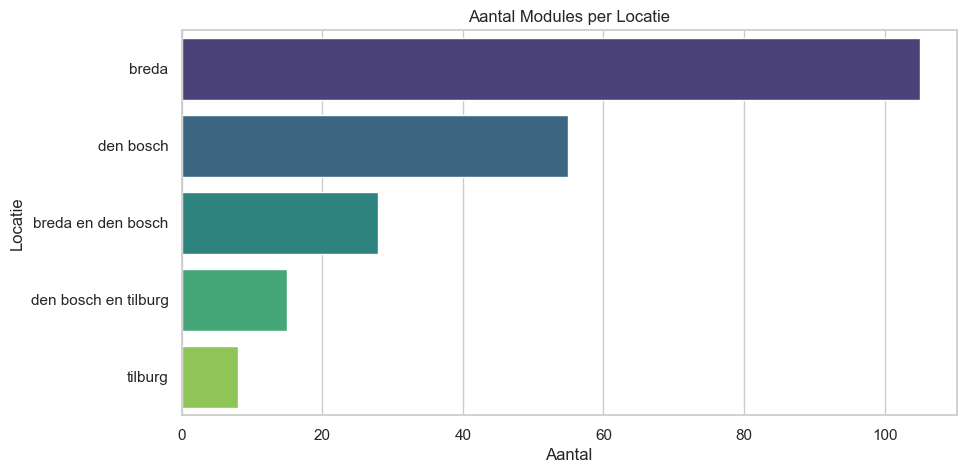

In [5]:
# Waar zijn de modules?
plt.figure(figsize=(10, 5))
sns.countplot(data=vkm, y='location', order=vkm['location'].value_counts().index, palette='viridis')
plt.title('Aantal Modules per Locatie')
plt.xlabel('Aantal')
plt.ylabel('Locatie')
plt.show()

En hoe zit het met de niveaus? Is alles voor beginners, of ook voor gevorderden?

C:\Users\yazan\AppData\Local\Temp\ipykernel_2260\2601557832.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=vkm, x='level', palette='magma')


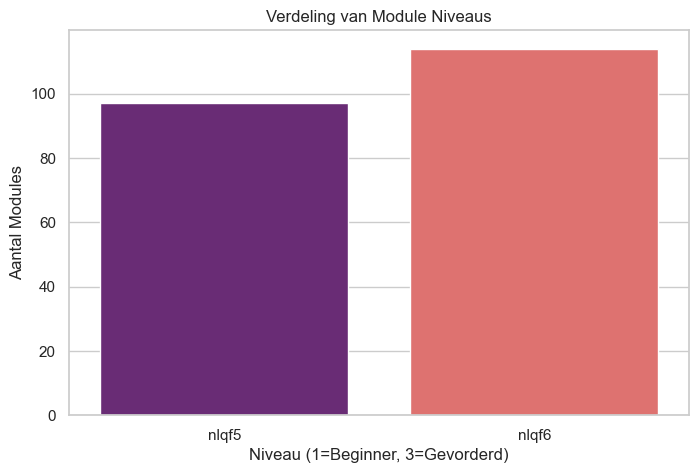

In [6]:
# Niveau verdeling
plt.figure(figsize=(8, 5))
sns.countplot(data=vkm, x='level', palette='magma')
plt.title('Verdeling van Module Niveaus')
plt.xlabel('Niveau (1=Beginner, 3=Gevorderd)')
plt.ylabel('Aantal Modules')
plt.show()

## 3. Waar praten we over? (WordClouds) ☁️

Laten we een "WordCloud" maken. Dit is een wolk van woorden waarbij de woorden die het vaakst voorkomen, het grootst worden afgebeeld. Dit geeft ons in één oogopslag een idee van de thema's.

## 4. Van Tekst naar Getallen (De Motor) ⚙️

Dit is waar de magie begint. Een computer kan geen tekst lezen zoals wij. Hij snapt niet dat "Zorg" en "Verpleging" bij elkaar horen. We moeten tekst omzetten in getallen.

Maar eerst moeten we de tekst **schoonmaken**! 🧹
In de originele data zitten veel woorden die geen betekenis hebben voor het onderwerp, zoals "de", "het", "een", "student", "module". Dit noemen we **stopwoorden**.
Ook willen we dat "lopen", "loopt" en "liep" als hetzelfde woord worden gezien. Dit heet **lemmatizing**.

We gebruiken hiervoor de bibliotheek `spacy` en een uitgebreide lijst met Nederlandse stopwoorden.

In [ ]:
import spacy
from sklearn.feature_extraction import text

# Probeer het Nederlandse model te laden, anders downloaden we het
try:
    nlp = spacy.load("nl_core_news_sm", disable=['parser', 'ner'])
except OSError:
    print("Spacy model niet gevonden. Downloaden...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "nl_core_news_sm"])
    nlp = spacy.load("nl_core_news_sm", disable=['parser', 'ner'])

# --- STOPWOORDEN LIJSTEN (Uitgebreid voor NL) ---
engelse_stopwoorden = list(text.ENGLISH_STOP_WORDS)

stopwoorden = [
    'de', 'en', 'van', 'ik', 'te', 'dat', 'die', 'in', 'een', 'hij', 'het', 'niet', 
    'zijn', 'is', 'was', 'op', 'aan', 'met', 'als', 'voor', 'had', 'er', 'maar', 
    'om', 'hem', 'dan', 'zou', 'of', 'wat', 'mijn', 'mens', 'dit', 'zo', 'door', 
    'over', 'ze', 'zich', 'bij', 'ook', 'tot', 'je', 'mij', 'uit', 'der', 'daar', 
    'haar', 'naar', 'als', 'bij', 'ons', 'u', 'deze', 'hoe', 'and', 'the', 'to', 'with', 
    'on', 'for', 'is', 'in', 'that', 'it', 'of', 'as', 'this', 'by', 'at', 'from', 'an', 
    'be', 'are', 'or', 'not', 'but', 'all', 'your', 'we', 'they', 'his', 'have', 'has', 'my', 
    'so', 'if', 'there', 'what', 'about', 'who', 'you', 'nog', 'kennis', 'studenten', 'module', 'students', 'gaan', 'waarbij', 'eerste',
]

extra_stopwoorden = [
    # Werkwoorden & Hulpwerkwoorden
    'worden','leren', 'maken', 'doen', 'kunnen', 'willen', 'zullen', 'moeten', 
    'gaan', 'volgen', 'gebruiken', 'leren', 'analyseren', 'ontwikkelen',
    'toepassen', 'bieden', 'kijken', 'zien', 'staan', 'vinden',
    
    # School/Context woorden
    'module', 'minor', 'student', 'studenten', 'project', 'opdracht', 
    'werk', 'praktijk', 'onderzoek', 'hbo', 'avans', 'opleiding',
    'groep', 'individueel', 'les', 'semester', 'punten', 'ec',
    
    # Ruis / Voorzetsels / Bijwoorden
    'volgens', 'hun', 'slag', 'waarbij', 'elkaar', 'eigen', 'binnen',
    'tijdens', 'waarin', 'diverse', 'verschillende', 'centraal', 'ntb'
]

# Samenvoegen en aan Spacy toevoegen
alle_extra_stopwoorden = extra_stopwoorden + stopwoorden

for woord in alle_extra_stopwoorden:
    nlp.vocab[woord].is_stop = True

# --- SCHOONMAAK FUNCTIE ---
def clean_and_lemmatize(text):
    if pd.isna(text): return ""
    # Zorg voor string en lowercase
    text = str(text).lower()
    doc = nlp(text)
    
    # Lemmatize en filter stopwoorden
    # We filteren ook op lengte > 2 om 'losse letters' te voorkomen
    lemmatized = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha and len(token.text) > 2]
    
    return ' '.join(lemmatized)

# We combineren naam, beschrijving en leeruitkomsten voor een rijk beeld
vkm['combined_content'] = vkm['name'].fillna('') + " " + vkm['description'].fillna('') + " " + vkm['module_tags'].fillna('')

print("Bezig met tekst opschonen en lemmatizen... (dit duurt even)")
vkm['processed_content'] = vkm['combined_content'].apply(clean_and_lemmatize)
print("Klaar!")

# Check het verschil
print(f"Origineel: {vkm['combined_content'].iloc[0][:100]}...")
print(f"Schoon:    {vkm['processed_content'].iloc[0][:100]}...")

Bezig met tekst opschonen en lemmatizen... (dit duurt even)
Klaar!
Origineel: kennismaking met psychologie in deze module leer je hoe je gedrag van jezelf en van anderen kunt beg...
Schoon:    kennismaking psychologie leren gedrag begrijpen beinvloed maken basistheorie psychologie bod komen o...


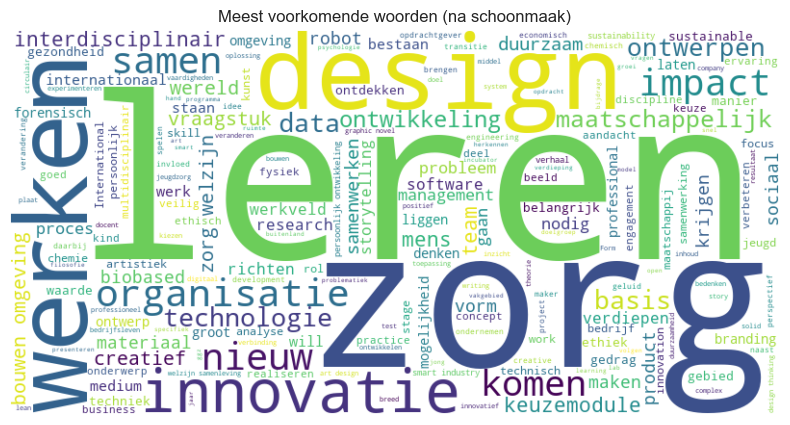

In [16]:
# Nu kunnen we een betere WordCloud maken met de SCHONE tekst
text_combined = " ".join(vkm['processed_content'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Meest voorkomende woorden (na schoonmaak)')
plt.show()

Nu de tekst schoon is, kunnen we de **TF-IDF** (Term Frequency - Inverse Document Frequency) berekenen.
*   **TF**: Hoe vaak komt een woord voor in deze module? (Vaak = belangrijk).
*   **IDF**: Komt het woord in *alle* modules voor? Dan is het *niet* belangrijk.

Omdat we de tekst al hebben schoongemaakt, hoeven we hier geen stopwoorden meer mee te geven.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# De Vectorizer instellen
tfidf = TfidfVectorizer(max_features=1000)

# De transformatie uitvoeren op de SCHONE tekst
tfidf_matrix = tfidf.fit_transform(vkm['processed_content'])

print(f"Onze tekst is nu een matrix van {tfidf_matrix.shape[0]} modules bij {tfidf_matrix.shape[1]} unieke woorden.")

Onze tekst is nu een matrix van 211 modules bij 1000 unieke woorden.


## 5. De Data Kaart (Dimensionality Reduction) 🗺️

We hebben nu voor elke module 1000 getallen (de TF-IDF scores). Dat kunnen we niet in een grafiek zetten. We willen terug naar 2 dimensies (X en Y), zodat we het kunnen plotten als een landkaart.

We gebruiken hiervoor drie technieken:
1.  **PCA**: De "grote lijnen" (zoals van bovenaf naar een berg kijken).
2.  **t-SNE**: De "details" (zoals inzoomen op de buurtjes).
3.  **UMAP**: De beste van beide werelden (snel en goed).

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# 1. PCA (Eerst reduceren om ruis te verminderen)
pca = PCA(n_components=0.73) # Behoud 73% van de variantie (zoals in EDA.ipynb)
pca_result = pca.fit_transform(tfidf_matrix.toarray())
print(f"PCA heeft de data teruggebracht naar {pca_result.shape[1]} dimensies.")

# 2. t-SNE (Voor lokale details)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(pca_result)

# 3. UMAP (De moderne favoriet)
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = umap_model.fit_transform(pca_result)

# Opslaan in het dataframe
vkm['tsne_x'] = tsne_result[:, 0]
vkm['tsne_y'] = tsne_result[:, 1]
vkm['umap_x'] = umap_result[:, 0]
vkm['umap_y'] = umap_result[:, 1]

PCA heeft de data teruggebracht naar 103 dimensies.


c:\Users\yazan\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Laten we de **UMAP** kaart bekijken. Elk puntje is een module. Modules die dicht bij elkaar liggen, lijken qua inhoud op elkaar. We kleuren ze in op basis van het niveau.

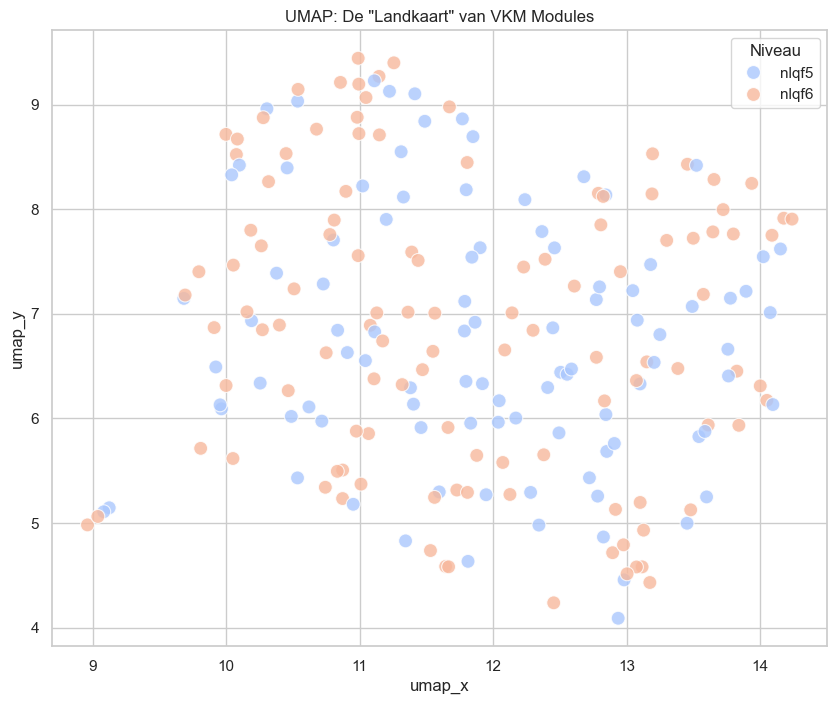

In [11]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=vkm, x='umap_x', y='umap_y', 
    hue='level', palette='coolwarm', s=100, alpha=0.8
)
plt.title('UMAP: De "Landkaart" van VKM Modules')
plt.legend(title='Niveau')
plt.show()

## 6. Automatisch Groeperen (Clustering) 🧩

We zien al wolkjes op de kaart. Laten we de computer vragen om deze wolkjes officieel te maken. Dit heet **Clustering**. We gebruiken KMeans om 6 groepen te maken.

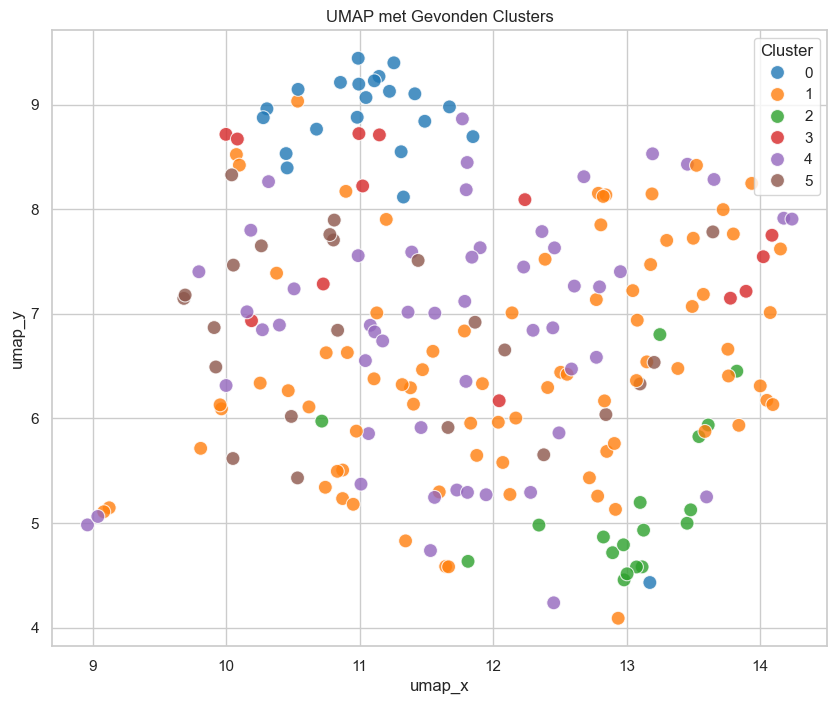

In [12]:
from sklearn.cluster import KMeans

# KMeans clustering op de TF-IDF matrix
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
vkm['cluster'] = kmeans.fit_predict(tfidf_matrix)

# Plotten met de nieuwe clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=vkm, x='umap_x', y='umap_y', 
    hue='cluster', palette='tab10', s=100, alpha=0.8
)
plt.title('UMAP met Gevonden Clusters')
plt.legend(title='Cluster')
plt.show()

## Conclusie 🎉

We hebben de data ingeladen, schoongemaakt (stopwoorden weg!), omgezet in getallen, en gevisualiseerd op een kaart.
De clusters die je ziet, zijn de basis voor ons aanbevelingssysteem. Als jij module A leuk vindt, en module B ligt in hetzelfde cluster, dan vind je module B waarschijnlijk ook leuk!

Bedankt voor het meelezen!